### Basic statistics

We're going to do some statistics on a real dataset. It is public: https://www.kaggle.com/datasets/akshatsharma0610/headbraincsv

In [1]:
# Basic staff
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('headbrain.csv') # Loading dataset
dataset

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590
...,...,...,...,...
232,2,2,3214,1110
233,2,2,3394,1215
234,2,2,3233,1104
235,2,2,3352,1170


In [3]:
gender, age, head, brain = [dataset[col] for col in ['Gender', 'Age Range', 'Head Size(cm^3)', 'Brain Weight(grams)']] # Assignments

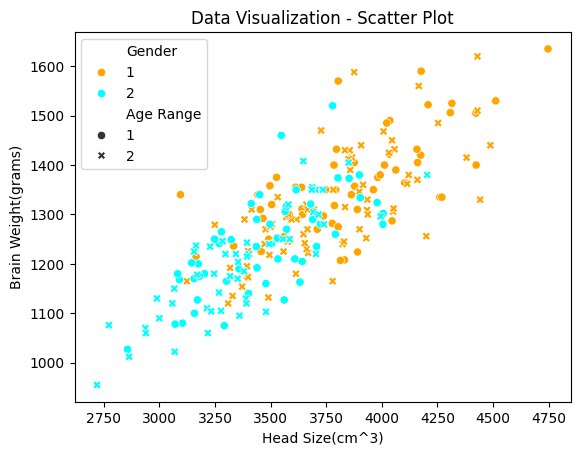

In [4]:
# Fast plot of data, 4 features
color = gender.map({1: 'red', 2: 'blue'})
size = dataset['Age Range'].map({1: 10, 2: 20})
plt.title('Data Visualization - Scatter Plot')
sb.scatterplot(data = dataset, x = 'Head Size(cm^3)', y = 'Brain Weight(grams)', hue = 'Gender', style = 'Age Range', palette = {1: 'orange', 2: 'cyan'})
plt.show()

#### Mean

The mean of a feature $x$ is defined as:

$$
    \frac{1}{N} \, \sum_{k = 1}^{N} \, x_k
$$

The weighted arithmetic mean is:

$$
    \frac{\sum_{k = 1}^{N} \, w_k \, x_k}{\sum_{k = 1}^{N} \, w_k}
$$

In [5]:
head_mean = int(head.mean()) # Head size mean
head_mean

3633

In [6]:
# Mean of head size for each gender
head_mean_gender_1, head_mean_gender_2 = dataset.groupby('Gender')['Head Size(cm^3)'].mean().values
head_mean_gender_1, head_mean_gender_2 = int(head_mean_gender_1), int(head_mean_gender_2)
head_mean_gender_1, head_mean_gender_2

(3798, 3420)

In [7]:
# Mean of head size for each age range
head_mean_age_1, head_mean_age_2 = dataset.groupby('Age Range')['Head Size(cm^3)'].mean().values
head_mean_age_1, head_mean_age_2 = int(head_mean_age_1), int(head_mean_age_2)
head_mean_age_1, head_mean_age_2

(3675, 3598)

In [8]:
brain_mean = int(brain.mean()) # Brain weight mean
brain_mean

1282

In [9]:
# Mean of brain size for each gender
brain_mean_gender_1, brain_mean_gender_2 = dataset.groupby('Gender')['Brain Weight(grams)'].mean().values
brain_mean_gender_1, brain_mean_gender_2 = int(brain_mean_gender_1), int(brain_mean_gender_2)
brain_mean_gender_1, brain_mean_gender_2

(1331, 1219)

In [10]:
# Mean of brain size for each age range
brain_mean_age_1, brain_mean_age_2 = dataset.groupby('Age Range')['Brain Weight(grams)'].mean().values
brain_mean_age_1, brain_mean_age_2 = int(brain_mean_age_1), int(brain_mean_age_2)
brain_mean_age_1, brain_mean_age_2

(1304, 1263)

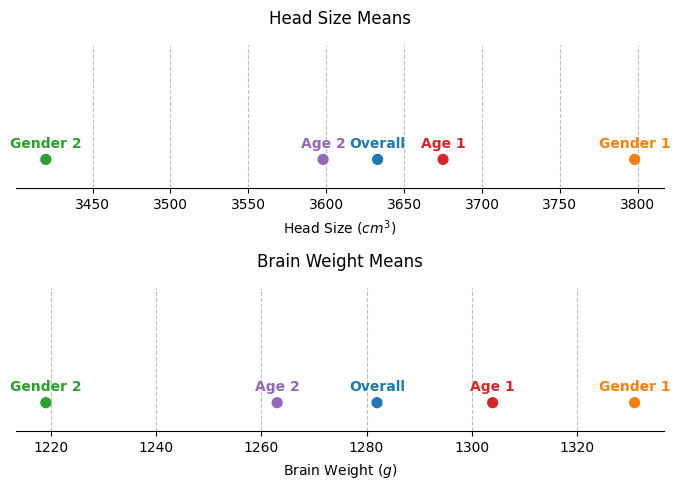

In [11]:
# Plot the results
head_means = [head_mean, head_mean_gender_1, head_mean_gender_2, head_mean_age_1, head_mean_age_2]
head_labels = ["Overall", "Gender 1", "Gender 2", "Age 1", "Age 2"]

brain_means = [brain_mean, brain_mean_gender_1, brain_mean_gender_2, brain_mean_age_1, brain_mean_age_2]
brain_labels = ["Overall", "Gender 1", "Gender 2", "Age 1", "Age 2"]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

_, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1, figsize = (7, 5))

# Subplot 1
ax1.scatter(head_means, [0] * len(head_means), c = colors, s = 50)

for x_val, label, color in zip(head_means, head_labels, colors):
    ax1.text(x = x_val, y = 0.03, s = label, color = color, fontweight = "bold", ha = "center", va = "bottom")
ax1.set_xlabel(r"Head Size ($cm^3$)", fontsize = 10, labelpad = 5)
ax1.set_title("Head Size Means", fontsize = 12, pad = 15)
ax1.set_ylim(- 0.1, 0.4)
ax1.grid(True, linestyle = '--', color = 'gray', alpha = 0.5)

# Subplot 2
ax2.scatter(brain_means, [0] * len(brain_means), c = colors, s = 50)

for x_val, label, color in zip(brain_means, brain_labels, colors):
    ax2.text(x = x_val, y = 0.03, s = label, color = color, fontweight = "bold", ha = "center", va = "bottom")
ax2.set_xlabel(r"Brain Weight ($g$)", fontsize = 10, labelpad = 5)
ax2.set_title("Brain Weight Means", fontsize = 12, pad = 15)
ax2.set_ylim(- 0.1, 0.4)
ax2.grid(True, linestyle = '--', color = 'gray', alpha = 0.5)

# Global style
for ax in [ax1, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()

#### Median

Given a list of sorted data, the median is defined as the "middle" number

In [12]:
brain_median, head_median = int(brain.median()), int(head.median()) # Brain and head sizes medians
brain_median, head_median

(1280, 3614)

#### Mode

Mode is the most frequent number that appears in a dataset

In [13]:
brain_mode, head_mode = int(brain.mode().squeeze()), int(head.mode().squeeze()) # Modes
brain_mode, head_mode

(1350, 3394)

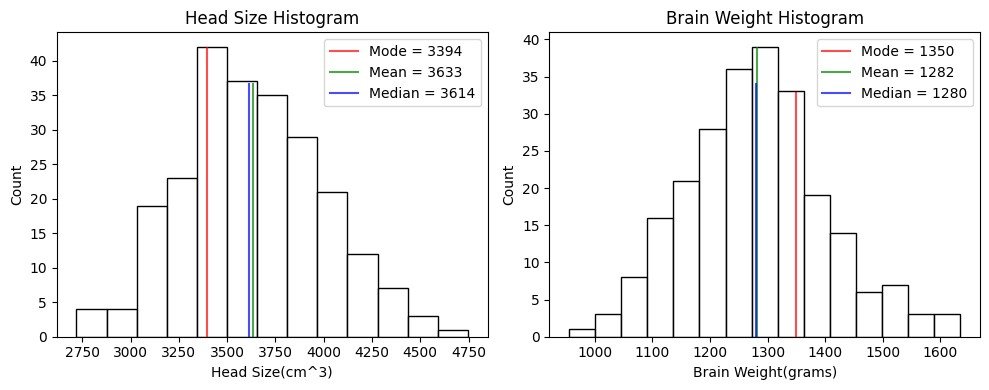

In [14]:
# Histograms plots
fig, axes = plt.subplots(1, 2, figsize = (10, 4))

# Plot head size
axes[0].set_title('Head Size Histogram')
sb.histplot(data = dataset, x = 'Head Size(cm^3)', color = 'white', ax = axes[0])
axes[0].axvline(x = head_mode, color = 'red', linestyle = '-', alpha = 0.7, ymax = 0.95, label = f'Mode = {head_mode}')
axes[0].axvline(x = head_mean, color = 'green', linestyle = '-', alpha = 0.7, ymax = 0.83, label = f'Mean = {head_mean}')
axes[0].axvline(x = head_median, color = 'blue', linestyle = '-', alpha = 0.7, ymax = 0.83, label = f'Median = {head_median}')
axes[0].legend(loc = 'best')

# Plot brain weight
axes[1].set_title('Brain Weight Histogram')
sb.histplot(data = dataset, x = 'Brain Weight(grams)', color = 'white', ax = axes[1])
axes[1].axvline(x = brain_mode, color = 'red', linestyle = '-', alpha = 0.7, ymax = 0.8, label = f'Mode = {brain_mode}')
axes[1].axvline(x = brain_mean, color = 'green', linestyle = '-', alpha = 0.7, ymax = 0.95, label = f'Mean = {brain_mean}')
axes[1].axvline(x = brain_median, color = 'blue', linestyle = '-', alpha = 0.7, ymax = 0.83, label = f'Median = {brain_median}')
axes[1].legend(loc = 'best')

plt.tight_layout()
plt.show()


#### Variance and standard deviation

Variance of a feature $x$ is just:

$$
    \frac{1}{N} \, \sum_{k = 1}^{N} \, \left( x_{k} - \operatorname{mean}(x) \right)^{2}
$$

Take its square root to compute standard deviation.

In [15]:
brain_std, head_std = round(brain.std(), 2), round(head.std(), 2) # Standard deviations
brain_std, head_std

(np.float64(120.34), np.float64(365.26))

# Covariance and correlation

Covariance between two features $x$ and $y$ is defined as:

$$
    \frac{1}{N} \, \sum_{k = 1}^{N} \, \left( x_{k} - \operatorname{mean}(x) \right) \, \left( y_{k} - \operatorname{mean}(y) \right)
$$

Correlation is just:

$$
    \frac{\operatorname{Cov}(x, y)}{\sigma_x \, \sigma_y}
$$

In [16]:
cov, corr = round(brain.cov(head), 2), round(brain.corr(head), 2) # Covariance and correlation of brain vs head
cov, corr

(np.float64(35145.66), np.float64(0.8))

In [17]:
dataset.cov(numeric_only = False) # Covariance matrix of the dataset

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
Gender,0.246764,-0.022009,-93.271741,-27.813398
Age Range,-0.022009,0.249768,-19.245459,-10.190356
Head Size(cm^3),-93.271741,-19.245459,133415.906708,35145.664182
Brain Weight(grams),-27.813398,-10.190356,35145.664182,14481.822892


In [18]:
dataset.corr(numeric_only = False) # Correlation matrix of the dataset

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
Gender,1.000000,-0.088652,-0.514050,-0.465266
Age Range,-0.088652,1.000000,-0.105428,-0.169438
Head Size(cm^3),-0.514050,-0.105428,1.000000,0.799570
Brain Weight(grams),-0.465266,-0.169438,0.799570,1.000000


#### Dissimilarity Matrix

Let's compute the Euclidean distance of data head size vs brain weight using SciPy capabilities

In [19]:
import numpy as np
from scipy.spatial.distance import pdist, squareform # We should combine them

In [20]:
diss = np.column_stack((head.to_numpy(), brain.to_numpy())) # 1 covert Pandas frames into numpy arrays and stack them
diss = pdist(X = diss, metric = 'euclidean') # 2 compute the distance array
diss = squareform(X = diss, force = 'tomatrix') # 3 visualize the distance array in square matrix form
diss /= np.max(diss) # 4 normalization with the maximum distance value, to have values between 0 and 1
diss = np.triu(diss) # 5 visualize only the coefficients above the main diagonal. The matrix is symmetric
diss

array([[0.        , 0.37806476, 0.14866367, ..., 0.63052688, 0.56808551,
        0.55828534],
       [0.        , 0.        , 0.24526371, ..., 0.25286187, 0.19006173,
        0.18219457],
       [0.        , 0.        , 0.        , ..., 0.49280841, 0.43210725,
        0.41916   ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.06364636,
        0.0742781 ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.02965892],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(237, 237))